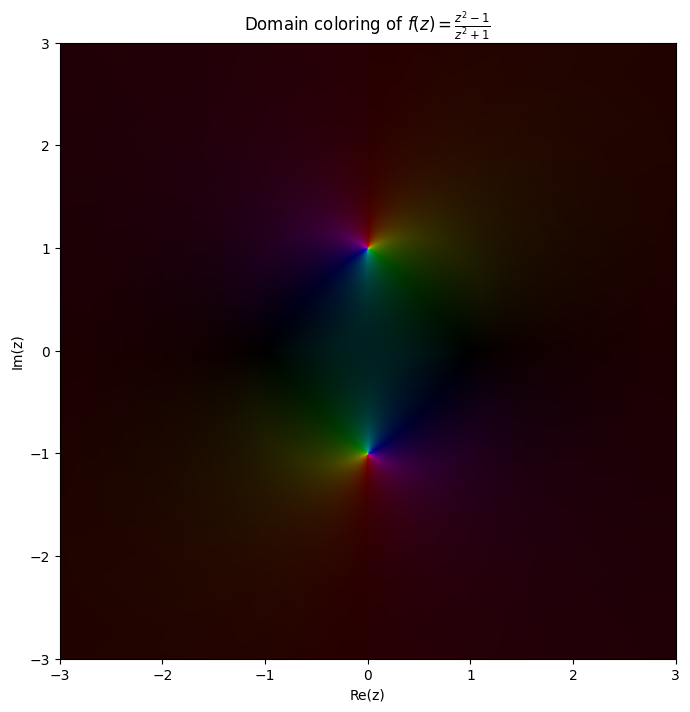

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Grid in complex plane
x = np.linspace(-3, 3, 800)
y = np.linspace(-3, 3, 800)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Complex function
F = (Z**2 - 1) / (Z**2 + 1)

# Domain coloring: hue = arg(F), brightness = magnitude (log scale)
H = np.angle(F) / (2*np.pi) % 1.0   # hue
S = np.ones_like(H)                  # full saturation
V = np.log(1 + np.abs(F))            # log‑scaled brightness
V = V / np.max(V)                    # normalize

# Combine into HSV and convert to RGB
HSV = np.dstack((H, S, V))
RGB = plt.cm.hsv(H)                  # alternative: use HSV2RGB manually
RGB[..., :3] *= V[..., np.newaxis]   # scale brightness
RGB = np.clip(RGB, 0, 1)

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(RGB, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title(r'Domain coloring of $f(z)=\frac{z^2-1}{z^2+1}$')
plt.show()

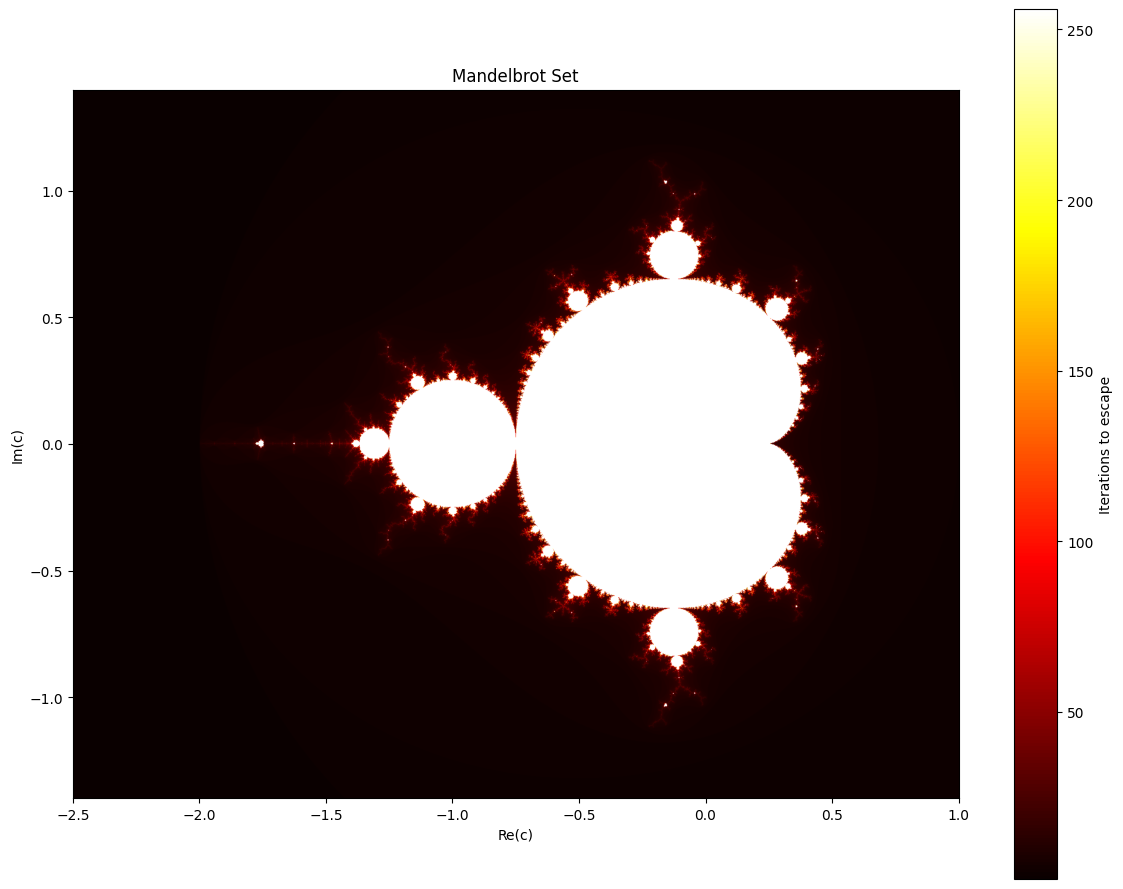

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot(c, max_iter):
    z = 0
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z*z + c
    return max_iter

# Image size and region
width, height = 2000, 1600
xmin, xmax = -2.5, 1.0
ymin, ymax = -1.4, 1.4

x = np.linspace(xmin, xmax, width)
y = np.linspace(ymin, ymax, height)
X, Y = np.meshgrid(x, y)
C = X + 1j*Y

# Vectorized iteration (faster)
max_iter = 256
Z = np.zeros_like(C, dtype=complex)
iterations = np.zeros(C.shape, dtype=int)

for i in range(max_iter):
    mask = np.abs(Z) <= 2
    Z[mask] = Z[mask]**2 + C[mask]
    iterations[mask] += 1

plt.figure(figsize=(12,9))
plt.imshow(iterations, extent=[xmin, xmax, ymin, ymax], cmap='hot', origin='lower')
plt.colorbar(label='Iterations to escape')
plt.title('Mandelbrot Set')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')
plt.tight_layout()
plt.show()

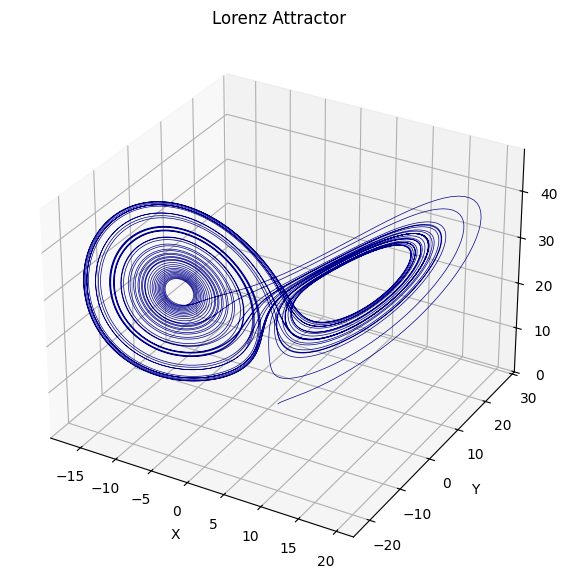

In [17]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x*y - beta*z
    return [dx, dy, dz]

# Initial condition
u0 = [1.0, 1.0, 1.0]
t_span = (0, 50)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

sol = solve_ivp(lorenz, t_span, u0, t_eval=t_eval, method='RK45')
x, y, z = sol.y

# 3D plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, color='darkblue')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Lorenz Attractor')
plt.show()

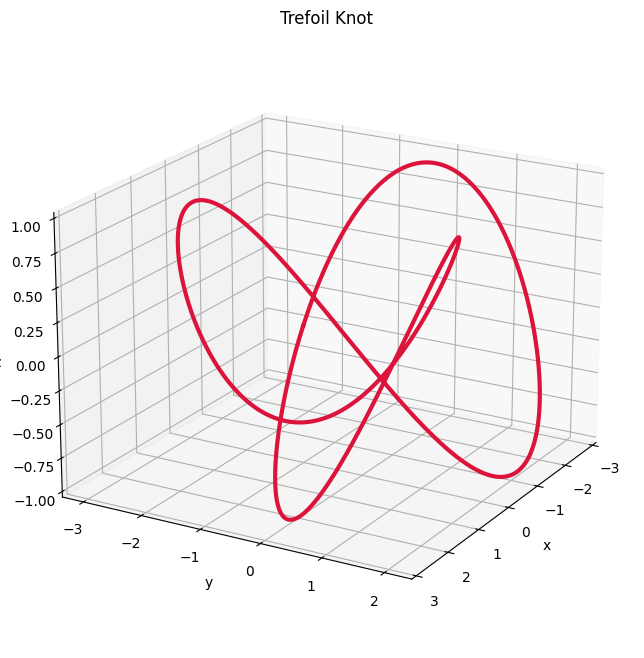

In [18]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 1000)
x = np.sin(t) + 2*np.sin(2*t)
y = np.cos(t) - 2*np.cos(2*t)
z = -np.sin(3*t)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=3, color='crimson')
ax.set_title('Trefoil Knot')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.view_init(elev=20, azim=30)
plt.show()

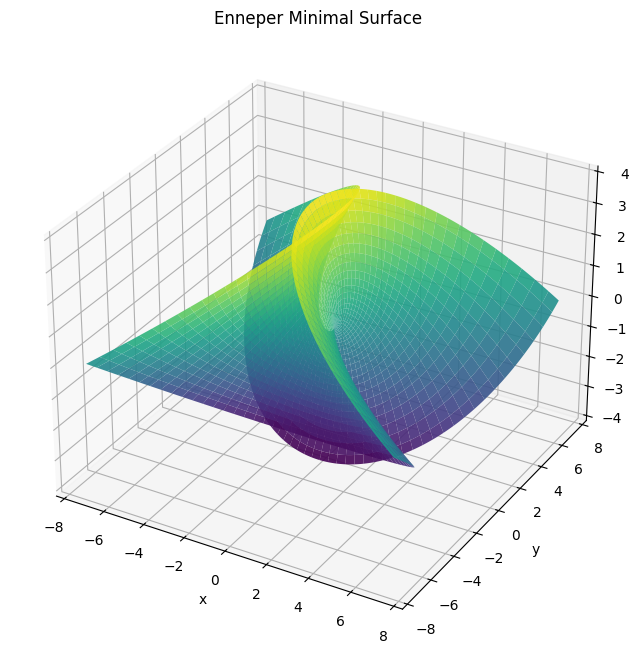

In [19]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-2, 2, 200)
v = np.linspace(-2, 2, 200)
U, V = np.meshgrid(u, v)

X = U - U**3/3 + U*V**2
Y = V - V**3/3 + V*U**2
Z = U**2 - V**2

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, edgecolor='none')
ax.set_title('Enneper Minimal Surface')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.show()

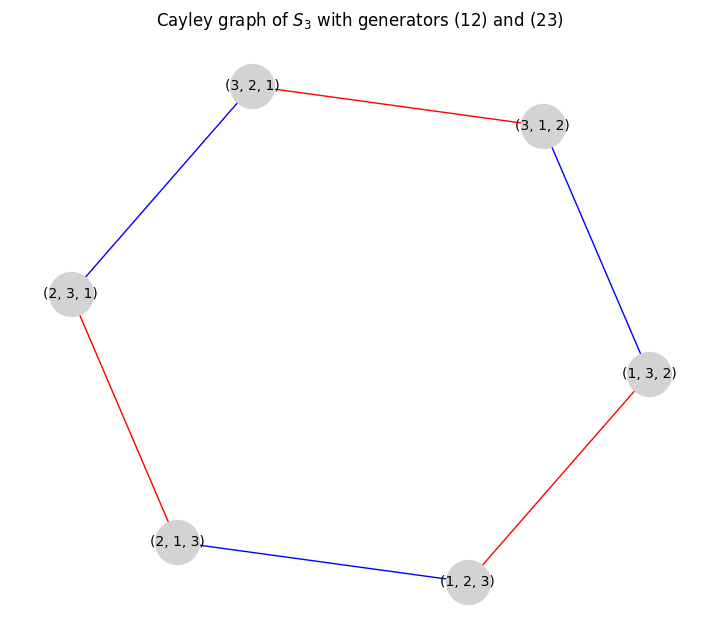

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

# Cayley graph of S_3 with generators (1,2) and (2,3)
G = nx.Graph()
# Add permutations as nodes (list of 6 tuples)
import itertools
nodes = list(itertools.permutations([1,2,3]))
G.add_nodes_from(nodes)
# Generators: swap first two, swap last two
gen1 = lambda p: (p[1], p[0], p[2])  # (1 2)
gen2 = lambda p: (p[0], p[2], p[1])  # (2 3)
for p in nodes:
    q1 = gen1(p)
    q2 = gen2(p)
    if not G.has_edge(p, q1):
        G.add_edge(p, q1, color='blue')
    if not G.has_edge(p, q2):
        G.add_edge(p, q2, color='red')

# Layout
pos = nx.spring_layout(G, seed=42)
edges = G.edges()
colors = [G[u][v]['color'] for u,v in edges]

plt.figure(figsize=(7,6))
nx.draw(G, pos, with_labels=True, node_color='lightgray', 
        edge_color=colors, node_size=1000, font_size=10)
plt.title("Cayley graph of $S_3$ with generators (12) and (23)")
plt.show()

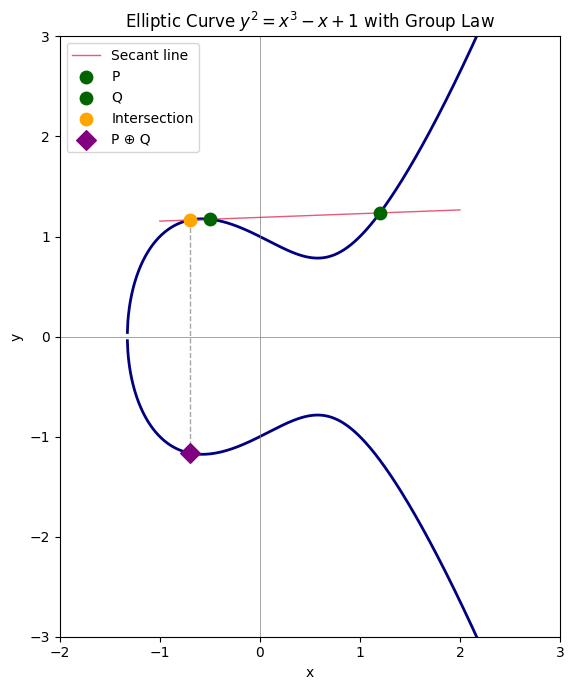

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Curve parameters: y^2 = x^3 - x + 1 (discriminant ≠ 0)
a, b = -1, 1

# Plot the real locus
x = np.linspace(-2, 3, 1000)
y_sq = x**3 + a*x + b
mask = y_sq >= 0
x_valid = x[mask]
y = np.sqrt(y_sq[mask])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(x_valid, y, 'navy', lw=2)
ax.plot(x_valid, -y, 'navy', lw=2)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# Pick two points on the curve
def point_on_curve(x0):
    y0 = np.sqrt(x0**3 + a*x0 + b)
    return np.array([x0, y0])

P = point_on_curve(-0.5)   # x=-0.5, positive y
Q = point_on_curve(1.2)

# Group law: P + Q
# Line through P, Q: slope m = (Qy - Py)/(Qx - Px)
m = (Q[1] - P[1]) / (Q[0] - P[0])
# Intersect: substitute y = m(x - Px) + Py into curve
# (m(x-Px)+Py)^2 = x^3 + ax + b
# Solve cubic: x^3 - m^2 x^2 + (a + 2 m^2 Px - 2 m Py)x + (b - (Py - m Px)^2) = 0
# Roots: Px, Qx, and Rx. Rx = m^2 - Px - Qx
Rx = m**2 - P[0] - Q[0]
Ry = m*(Rx - P[0]) + P[1]
R_ref = np.array([Rx, -Ry])  # reflect across x-axis = P+Q

# Plot the line and points
x_line = np.linspace(-1, 2, 100)
y_line = m*(x_line - P[0]) + P[1]
ax.plot(x_line, y_line, 'crimson', lw=1, alpha=0.7, label='Secant line')

# Dashed vertical from intersection to sum
ax.plot([Rx, Rx], [Ry, -Ry], 'gray', lw=1, ls='--', alpha=0.7)

# Points
ax.scatter(*P, c='darkgreen', s=80, zorder=5, label='P')
ax.scatter(*Q, c='darkgreen', s=80, zorder=5, label='Q')
ax.scatter(Rx, Ry, c='orange', s=80, zorder=5, label='Intersection')
ax.scatter(*R_ref, c='purple', s=100, zorder=5, marker='D', label='P ⊕ Q')

ax.set_xlim(-2, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.set_title(r'Elliptic Curve $y^2 = x^3 - x + 1$ with Group Law')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

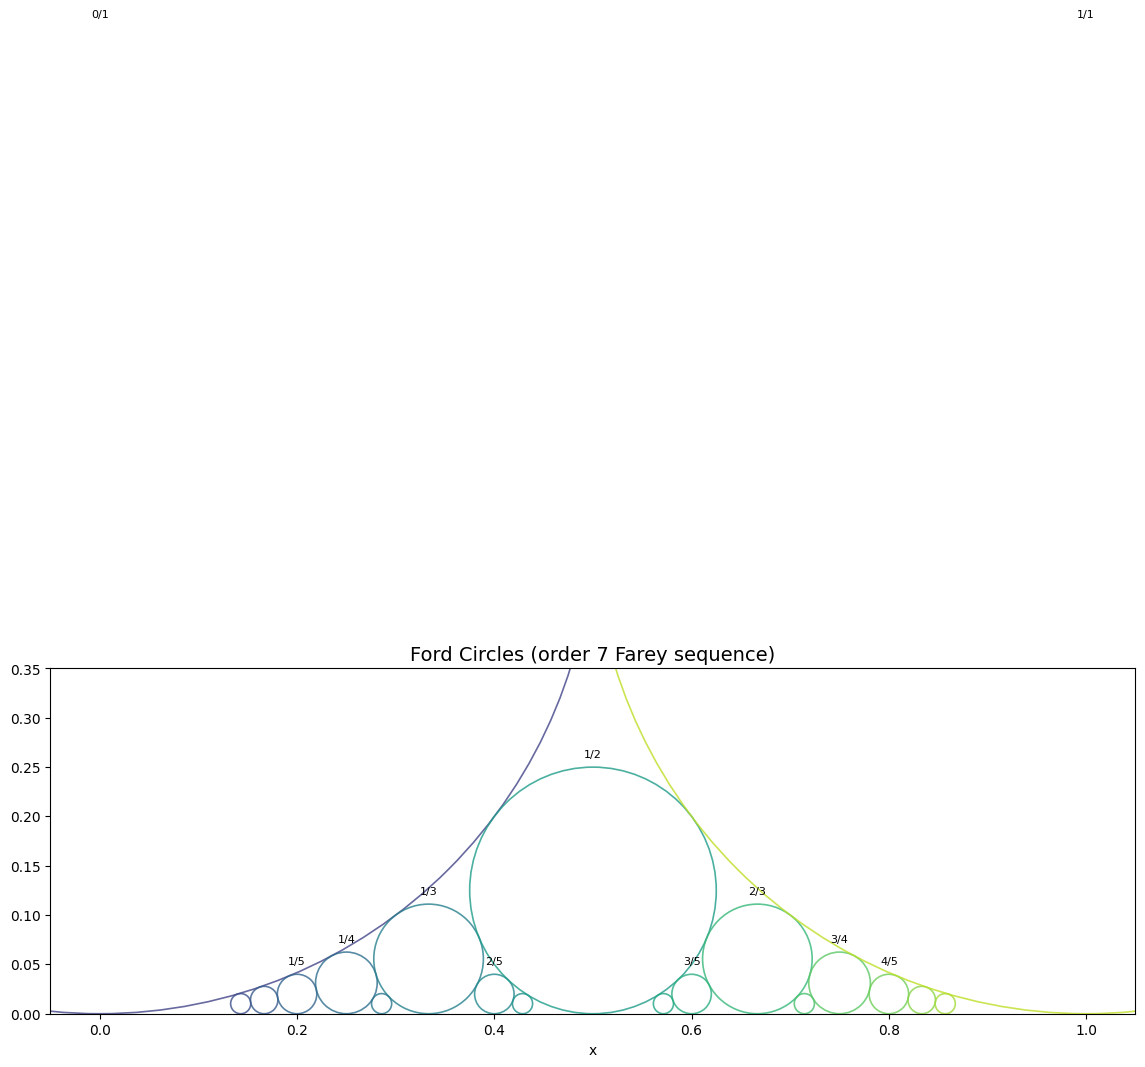

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

def farey(n):
    """Farey sequence of order n: sorted unique reduced fractions in [0,1]."""
    fracs = [(0, 1), (1, 1)]
    for q in range(1, n+1):
        for p in range(1, q):
            if gcd(p, q) == 1:
                fracs.append((p, q))
    fracs.sort(key=lambda f: f[0]/f[1])
    return fracs

n = 7
fracs = farey(n)

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fracs)))

for i, (p, q) in enumerate(fracs):
    x = p / q
    r = 1 / (2 * q**2)
    circle = plt.Circle((x, r), r, fill=False, color=colors[i], lw=1.2, alpha=0.8)
    ax.add_patch(circle)
    if q <= 5:  # label only simpler fractions
        ax.text(x, 2*r + 0.01, f'{p}/{q}', ha='center', fontsize=8)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, 0.35)
ax.set_aspect('equal')
ax.set_title('Ford Circles (order 7 Farey sequence)', fontsize=14)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('x')
plt.show()

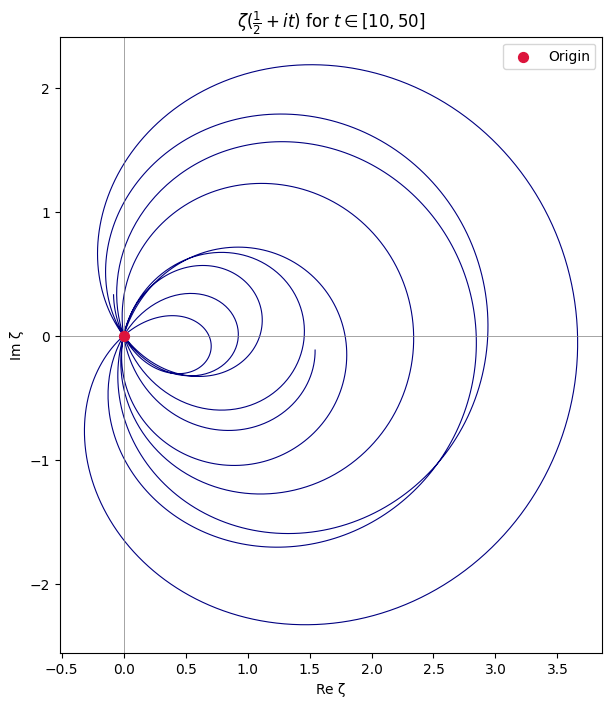

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta  # pip install mpmath

t = np.linspace(10, 50, 2000)
s = 0.5 + 1j*t
zeta_vals = np.array([complex(zeta(si)) for si in s])

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(zeta_vals.real, zeta_vals.imag, 'navy', lw=0.8)
ax.scatter(0, 0, c='crimson', s=50, zorder=5, label='Origin')
ax.set_xlabel('Re ζ')
ax.set_ylabel('Im ζ')
# Fixed: escape the LaTeX properly, or use a simpler format
ax.set_title(r'$\zeta(\frac{1}{2} + it)$ for $t \in [10, 50]$')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.legend()
ax.set_aspect('equal')
plt.show()

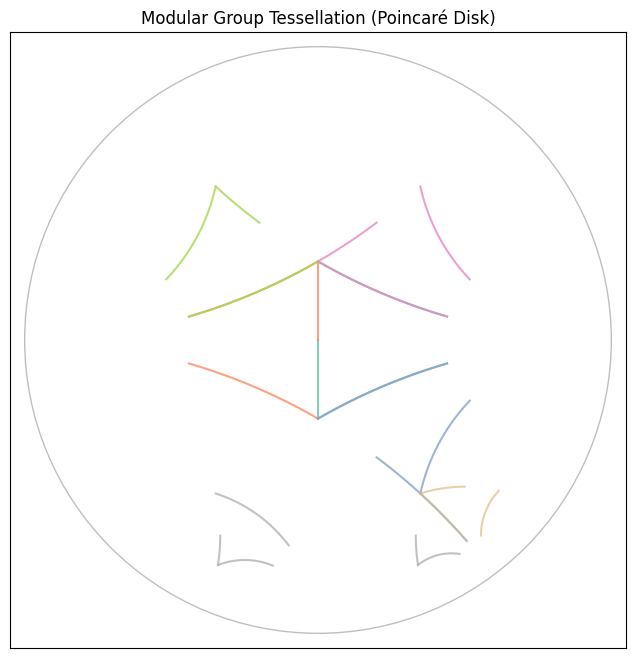

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def to_disk(z):
    """Map upper half-plane to Poincaré disk."""
    return (z - 1j) / (z + 1j)

def mobius(z, a, b, c, d):
    """Apply Möbius transformation (a*z+b)/(c*z+d)."""
    return (a*z + b) / (c*z + d)

# Fundamental domain boundary in upper half-plane
# Arc: |z| = 1 from e^{iπ/3} to i, then vertical lines Re(z) = ±1/2
theta = np.linspace(np.pi/3, np.pi/2, 200)
arc = np.exp(1j*theta)

left_edge = -0.5 + 1j*np.linspace(np.sin(np.pi/3), 2.5, 200)
right_edge = 0.5 + 1j*np.linspace(np.sin(np.pi/3), 2.5, 200)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)

# Draw unit circle (boundary of disk)
circle = plt.Circle((0, 0), 1, fill=False, color='gray', lw=1, alpha=0.5)
ax.add_patch(circle)

# Some SL2(Z) matrices (modular group generators and their products)
matrices = [
    (1, 0, 0, 1),   # identity
    (0, -1, 1, 0),  # S
    (1, 1, 0, 1),   # T
    (1, -1, 0, 1),  # T^{-1}
    (0, -1, 1, 1),  # S T
    (1, 1, 1, 0),   # T S
    (2, -1, 1, 0),
    (1, 1, 1, 2),
    (2, 1, 1, 1),
]

colors = plt.cm.Set2(np.linspace(0, 1, len(matrices)))

for (a,b,c,d), col in zip(matrices, colors):
    # Apply to arc
    z = mobius(arc, a, b, c, d)
    w = to_disk(z)
    ax.plot(w.real, w.imag, color=col, lw=1.5, alpha=0.8)
    # Apply to left edge
    z = mobius(left_edge, a, b, c, d)
    w = to_disk(z)
    ax.plot(w.real, w.imag, color=col, lw=1.5, alpha=0.8)
    # Apply to right edge
    z = mobius(right_edge, a, b, c, d)
    w = to_disk(z)
    ax.plot(w.real, w.imag, color=col, lw=1.5, alpha=0.8)

ax.set_title('Modular Group Tessellation (Poincaré Disk)')
ax.set_xticks([]); ax.set_yticks([])
plt.show()

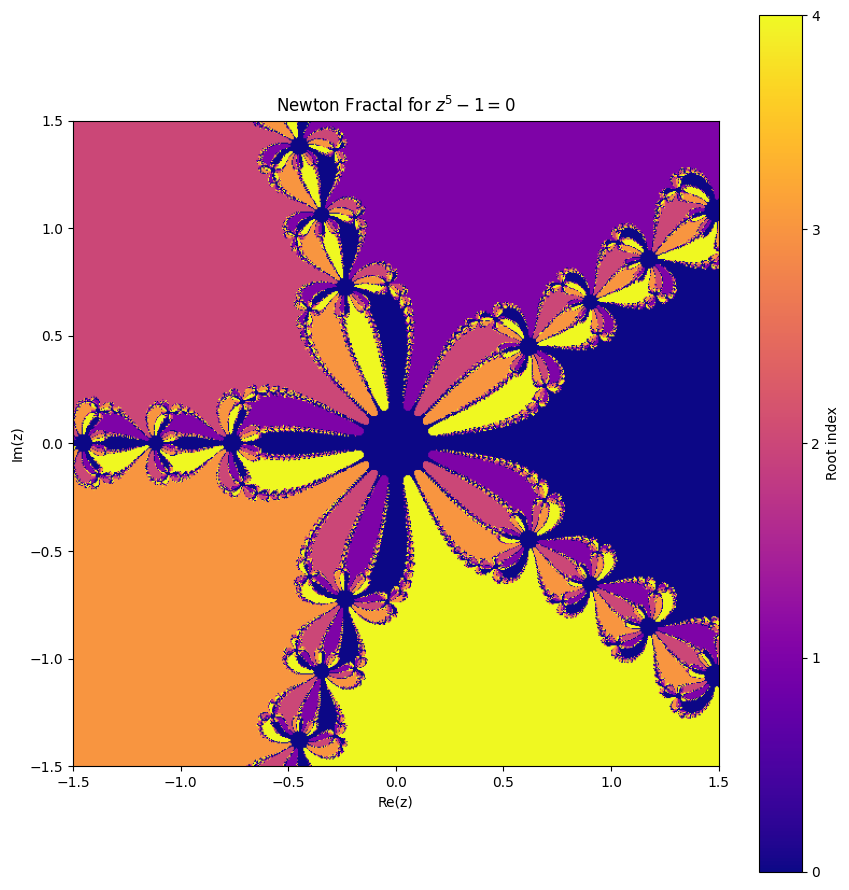

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def newton_fractal(f, fprime, roots, x_range, y_range, size=800, max_iter=30):
    x = np.linspace(*x_range, size)
    y = np.linspace(*y_range, size)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y
    
    for i in range(max_iter):
        Z = Z - f(Z)/fprime(Z)
    
    # Find nearest root for each point
    root_idx = np.zeros(Z.shape, dtype=int)
    for i, r in enumerate(roots):
        mask = np.abs(Z - r) < 1e-6
        root_idx[mask] = i
    
    return root_idx

f = lambda z: z**5 - 1
fprime = lambda z: 5*z**4
roots = [np.exp(2j*np.pi*k/5) for k in range(5)]

result = newton_fractal(f, fprime, roots, (-1.5, 1.5), (-1.5, 1.5), size=600)

plt.figure(figsize=(9, 9))
plt.imshow(result, extent=[-1.5, 1.5, -1.5, 1.5], cmap='plasma', origin='lower')
plt.colorbar(ticks=range(5), label='Root index')
plt.title("Newton Fractal for $z^5 - 1 = 0$")
plt.xlabel('Re(z)'); plt.ylabel('Im(z)')
plt.tight_layout()
plt.show()

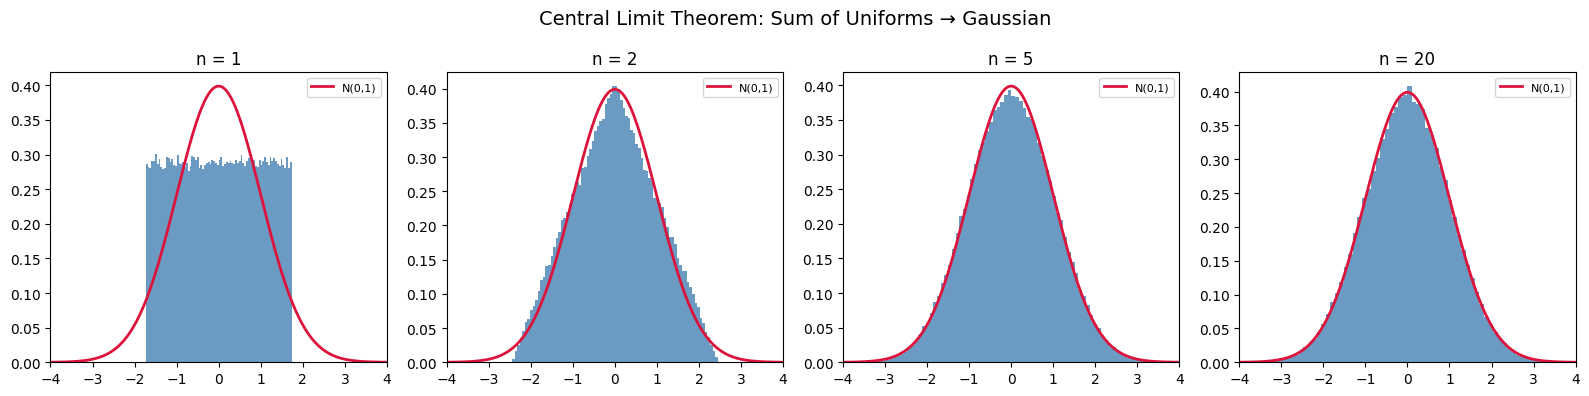

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
N = 200000

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
n_vals = [1, 2, 5, 20]

for ax, n in zip(axes, n_vals):
    # Sum of n uniform[0,1] then standardize
    samples = np.sum(np.random.uniform(0, 1, (N, n)), axis=1)
    samples = (samples - n*0.5) / np.sqrt(n/12)  # mean 0, std 1
    
    ax.hist(samples, bins=80, density=True, color='steelblue', alpha=0.8)
    x = np.linspace(-4, 4, 200)
    ax.plot(x, norm.pdf(x), 'crimson', lw=2, label='N(0,1)')
    ax.set_title(f'n = {n}')
    ax.set_xlim(-4, 4)
    ax.legend(fontsize=8)

fig.suptitle('Central Limit Theorem: Sum of Uniforms → Gaussian', fontsize=14)
plt.tight_layout()
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/var/folders/6f/twg_bwys7xb6mgr86_05x41m0000gn/T/ipykernel_1136/3804989298.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Hyperboloid Model of $\mathbb{H}^2$')


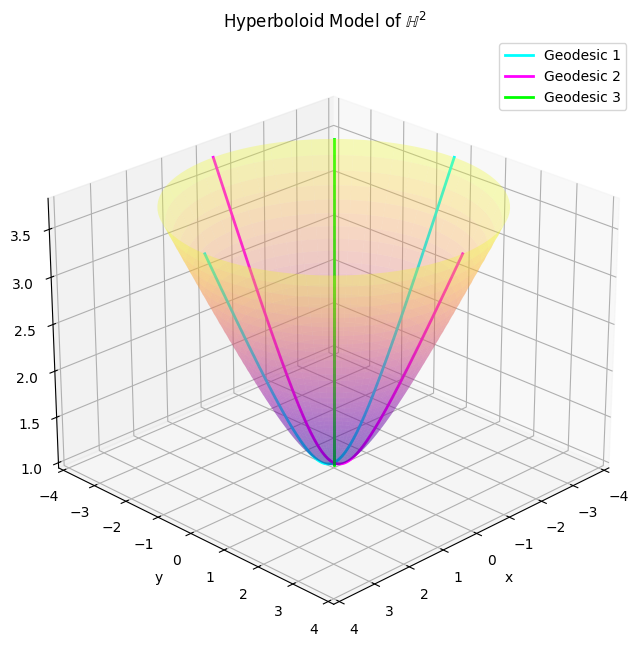

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Generate hyperboloid points
theta = np.linspace(0, 2*np.pi, 100)
rho = np.linspace(0, 2, 50)
Theta, Rho = np.meshgrid(theta, rho)
X = np.sinh(Rho) * np.cos(Theta)
Y = np.sinh(Rho) * np.sin(Theta)
Z = np.cosh(Rho)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.3, cmap='plasma', edgecolor='none')

# Draw some geodesics (great hyperbolas)
t = np.linspace(-2, 2, 400)
# Plane y=0 -> geodesic in x-z plane
ax.plot(np.sinh(t), np.zeros_like(t), np.cosh(t), 'cyan', lw=2, label='Geodesic 1')
# Plane x=0
ax.plot(np.zeros_like(t), np.sinh(t), np.cosh(t), 'magenta', lw=2, label='Geodesic 2')
# Plane x=y
ax.plot(np.sinh(t)/np.sqrt(2), np.sinh(t)/np.sqrt(2), np.cosh(t), 'lime', lw=2, label='Geodesic 3')

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Hyperboloid Model of $\mathbb{H}^2$')
ax.legend()
ax.view_init(elev=25, azim=45)
plt.show()

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.integrate import solve_ivp
from scipy.stats import norm
from mpmath import zeta
from math import gcd
import itertools

# ============================================================
# SETUP: Create output directory on desktop
# ============================================================
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
output_dir = os.path.join(desktop_path, "math_visualizations")
os.makedirs(output_dir, exist_ok=True)

def save_fig(fig, filename):
    """Save figure to desktop folder with high DPI."""
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Saved: {filepath}")

# ============================================================
# 1. DOMAIN COLORING
# ============================================================
print("Generating 1/14: Domain Coloring...")
x = np.linspace(-3, 3, 800)
y = np.linspace(-3, 3, 800)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y
F = (Z**2 - 1) / (Z**2 + 1)
H = np.angle(F) / (2*np.pi) % 1.0
S = np.ones_like(H)
V = np.log(1 + np.abs(F))
V = V / np.max(V)
RGB = plt.cm.hsv(H)
RGB[..., :3] *= V[..., np.newaxis]
RGB = np.clip(RGB, 0, 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(RGB, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
ax.set_title('Domain coloring of f(z) = (z²−1)/(z²+1)')
save_fig(fig, '01_domain_coloring.png')
plt.close()

# ============================================================
# 2. MANDELBROT SET
# ============================================================
print("Generating 2/14: Mandelbrot Set...")
width, height = 2000, 1600
xmin, xmax = -2.5, 1.0
ymin, ymax = -1.4, 1.4
x = np.linspace(xmin, xmax, width)
y = np.linspace(ymin, ymax, height)
X, Y = np.meshgrid(x, y)
C = X + 1j*Y
max_iter = 256
Z = np.zeros_like(C, dtype=complex)
iterations = np.zeros(C.shape, dtype=int)

for i in range(max_iter):
    mask = np.abs(Z) <= 2
    Z[mask] = Z[mask]**2 + C[mask]
    iterations[mask] += 1

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(iterations, extent=[xmin, xmax, ymin, ymax], cmap='hot', origin='lower')
ax.set_title('Mandelbrot Set')
ax.set_xlabel('Re(c)'); ax.set_ylabel('Im(c)')
save_fig(fig, '02_mandelbrot_set.png')
plt.close()

# ============================================================
# 3. LORENZ ATTRACTOR
# ============================================================
print("Generating 3/14: Lorenz Attractor...")
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x*y - beta*z
    return [dx, dy, dz]

u0 = [1.0, 1.0, 1.0]
t_eval = np.linspace(0, 50, 10000)
sol = solve_ivp(lorenz, (0, 50), u0, t_eval=t_eval, method='RK45')
x, y, z = sol.y

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, color='darkblue')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Lorenz Attractor')
save_fig(fig, '03_lorenz_attractor.png')
plt.close()

# ============================================================
# 4. TREFOIL KNOT
# ============================================================
print("Generating 4/14: Trefoil Knot...")
t = np.linspace(0, 2*np.pi, 1000)
x = np.sin(t) + 2*np.sin(2*t)
y = np.cos(t) - 2*np.cos(2*t)
z = -np.sin(3*t)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=3, color='crimson')
ax.set_title('Trefoil Knot')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.view_init(elev=20, azim=30)
save_fig(fig, '04_trefoil_knot.png')
plt.close()

# ============================================================
# 5. ENNEPER MINIMAL SURFACE
# ============================================================
print("Generating 5/14: Enneper Minimal Surface...")
u = np.linspace(-2, 2, 200)
v = np.linspace(-2, 2, 200)
U, V = np.meshgrid(u, v)
X = U - U**3/3 + U*V**2
Y = V - V**3/3 + V*U**2
Z = U**2 - V**2

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, edgecolor='none')
ax.set_title('Enneper Minimal Surface')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
save_fig(fig, '05_enneper_surface.png')
plt.close()

# ============================================================
# 6. CAYLEY GRAPH OF S3
# ============================================================
print("Generating 6/14: Cayley Graph of S3...")
import networkx as nx

nodes = list(itertools.permutations([1,2,3]))
G = nx.Graph()
G.add_nodes_from(nodes)
gen1 = lambda p: (p[1], p[0], p[2])
gen2 = lambda p: (p[0], p[2], p[1])
for p in nodes:
    q1, q2 = gen1(p), gen2(p)
    if not G.has_edge(p, q1):
        G.add_edge(p, q1, color='blue')
    if not G.has_edge(p, q2):
        G.add_edge(p, q2, color='red')

pos = nx.spring_layout(G, seed=42)
edges = G.edges()
colors = [G[u][v]['color'] for u,v in edges]

fig, ax = plt.subplots(figsize=(7, 6))
nx.draw(G, pos, with_labels=True, node_color='lightgray', 
        edge_color=colors, node_size=1000, font_size=10, ax=ax)
ax.set_title("Cayley graph of S₃ with generators (12) and (23)")
save_fig(fig, '06_cayley_graph_S3.png')
plt.close()

# ============================================================
# 7. ELLIPTIC CURVE GROUP LAW
# ============================================================
print("Generating 7/14: Elliptic Curve Group Law...")
a, b = -1, 1
x = np.linspace(-2, 3, 1000)
y_sq = x**3 + a*x + b
mask = y_sq >= 0
x_valid, y = x[mask], np.sqrt(y_sq[mask])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(x_valid, y, 'navy', lw=2)
ax.plot(x_valid, -y, 'navy', lw=2)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

def point_on_curve(x0):
    y0 = np.sqrt(x0**3 + a*x0 + b)
    return np.array([x0, y0])

P = point_on_curve(-0.5)
Q = point_on_curve(1.2)
m = (Q[1] - P[1]) / (Q[0] - P[0])
Rx = m**2 - P[0] - Q[0]
Ry = m*(Rx - P[0]) + P[1]
R_ref = np.array([Rx, -Ry])

x_line = np.linspace(-1, 2, 100)
y_line = m*(x_line - P[0]) + P[1]
ax.plot(x_line, y_line, 'crimson', lw=1, alpha=0.7, label='Secant line')
ax.plot([Rx, Rx], [Ry, -Ry], 'gray', lw=1, ls='--', alpha=0.7)
ax.scatter(*P, c='darkgreen', s=80, zorder=5, label='P')
ax.scatter(*Q, c='darkgreen', s=80, zorder=5, label='Q')
ax.scatter(Rx, Ry, c='orange', s=80, zorder=5, label='Intersection')
ax.scatter(*R_ref, c='purple', s=100, zorder=5, marker='D', label='P ⊕ Q')
ax.set_xlim(-2, 3); ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.set_title('Elliptic Curve y² = x³ − x + 1 with Group Law')
ax.set_xlabel('x'); ax.set_ylabel('y')
save_fig(fig, '07_elliptic_curve_group_law.png')
plt.close()

# ============================================================
# 8. FORD CIRCLES & FAREY SEQUENCE
# ============================================================
print("Generating 8/14: Ford Circles...")
def farey(n):
    fracs = [(0, 1), (1, 1)]
    for q in range(1, n+1):
        for p in range(1, q):
            if gcd(p, q) == 1:
                fracs.append((p, q))
    fracs.sort(key=lambda f: f[0]/f[1])
    return fracs

fracs = farey(7)
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(fracs)))
for i, (p, q) in enumerate(fracs):
    x = p / q
    r = 1 / (2 * q**2)
    circle = plt.Circle((x, r), r, fill=False, color=colors[i], lw=1.2, alpha=0.8)
    ax.add_patch(circle)
    if q <= 5:
        ax.text(x, 2*r + 0.01, f'{p}/{q}', ha='center', fontsize=8)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(0, 0.35)
ax.set_aspect('equal')
ax.set_title('Ford Circles (Farey sequence order 7)')
ax.set_xlabel('x')
save_fig(fig, '08_ford_circles.png')
plt.close()

# ============================================================
# 9. RIEMANN ZETA ON CRITICAL LINE
# ============================================================
print("Generating 9/14: Riemann Zeta Function...")
t = np.linspace(10, 50, 2000)
s = 0.5 + 1j*t
zeta_vals = np.array([complex(zeta(si)) for si in s])

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(zeta_vals.real, zeta_vals.imag, 'navy', lw=0.8)
ax.scatter(0, 0, c='crimson', s=50, zorder=5, label='Origin')
ax.set_xlabel('Re ζ'); ax.set_ylabel('Im ζ')
ax.set_title('ζ(1/2 + it) for t ∈ [10, 50]')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.legend(); ax.set_aspect('equal')
save_fig(fig, '09_riemann_zeta_critical_line.png')
plt.close()

# ============================================================
# 10. MODULAR GROUP TESSELLATION
# ============================================================
print("Generating 10/14: Modular Group Tessellation...")
def to_disk(z):
    return (z - 1j) / (z + 1j)

def mobius(z, a, b, c, d):
    return (a*z + b) / (c*z + d)

theta = np.linspace(np.pi/3, np.pi/2, 200)
arc = np.exp(1j*theta)
left_edge = -0.5 + 1j*np.linspace(np.sin(np.pi/3), 2.5, 200)
right_edge = 0.5 + 1j*np.linspace(np.sin(np.pi/3), 2.5, 200)

matrices = [
    (1, 0, 0, 1), (0, -1, 1, 0), (1, 1, 0, 1),
    (1, -1, 0, 1), (0, -1, 1, 1), (1, 1, 1, 0),
    (2, -1, 1, 0), (1, 1, 1, 2), (2, 1, 1, 1),
]
colors = plt.cm.Set2(np.linspace(0, 1, len(matrices)))

fig, ax = plt.subplots(figsize=(8, 8))
circle = plt.Circle((0, 0), 1, fill=False, color='gray', lw=1, alpha=0.5)
ax.add_patch(circle)

for (a,b,c,d), col in zip(matrices, colors):
    for curve in [arc, left_edge, right_edge]:
        z = mobius(curve, a, b, c, d)
        w = to_disk(z)
        ax.plot(w.real, w.imag, color=col, lw=1.5, alpha=0.8)

ax.set_aspect('equal'); ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
ax.set_title('Modular Group Tessellation (Poincaré Disk)')
ax.set_xticks([]); ax.set_yticks([])
save_fig(fig, '10_modular_group_tessellation.png')
plt.close()

# ============================================================
# 11. NEWTON FRACTAL
# ============================================================
print("Generating 11/14: Newton Fractal...")
def newton_fractal(f, fprime, roots, x_range, y_range, size=600, max_iter=30):
    x = np.linspace(*x_range, size)
    y = np.linspace(*y_range, size)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y
    for _ in range(max_iter):
        Z = Z - f(Z)/fprime(Z)
    root_idx = np.zeros(Z.shape, dtype=int)
    for i, r in enumerate(roots):
        root_idx[np.abs(Z - r) < 1e-6] = i
    return root_idx

f = lambda z: z**5 - 1
fprime = lambda z: 5*z**4
roots = [np.exp(2j*np.pi*k/5) for k in range(5)]
result = newton_fractal(f, fprime, roots, (-1.5, 1.5), (-1.5, 1.5), size=600)

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(result, extent=[-1.5, 1.5, -1.5, 1.5], cmap='plasma', origin='lower')
plt.colorbar(im, ticks=range(5), label='Root index')
ax.set_title('Newton Fractal for z⁵ − 1 = 0')
ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
save_fig(fig, '11_newton_fractal.png')
plt.close()

# ============================================================
# 12. HOMOTOPY: CIRCLE → FIGURE-8
# ============================================================
print("Generating 12/14: Homotopy Circle to Figure-8...")
t = np.linspace(0, 2*np.pi, 400)
s_vals = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, s in zip(axes, s_vals):
    x = np.cos(t)
    y = (1-s)*np.sin(t) + s*np.sin(2*t)
    ax.plot(x, y, 'teal', lw=2)
    ax.set_aspect('equal')
    ax.set_title(f's = {s:.2f}')
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Homotopy: Circle → Figure-Eight', fontsize=14)
save_fig(fig, '12_homotopy_circle_figure8.png')
plt.close()

# ============================================================
# 13. CENTRAL LIMIT THEOREM
# ============================================================
print("Generating 13/14: Central Limit Theorem...")
np.random.seed(42)
N = 200000

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
n_vals = [1, 2, 5, 20]
for ax, n in zip(axes, n_vals):
    samples = np.sum(np.random.uniform(0, 1, (N, n)), axis=1)
    samples = (samples - n*0.5) / np.sqrt(n/12)
    ax.hist(samples, bins=80, density=True, color='steelblue', alpha=0.8)
    x_range = np.linspace(-4, 4, 200)
    ax.plot(x_range, norm.pdf(x_range), 'crimson', lw=2, label='N(0,1)')
    ax.set_title(f'n = {n}'); ax.set_xlim(-4, 4)
    ax.legend(fontsize=8)
fig.suptitle('Central Limit Theorem: Sum of Uniforms → Gaussian', fontsize=14)
save_fig(fig, '13_central_limit_theorem.png')
plt.close()

# ============================================================
# 14. HYPERBOLOID MODEL OF H²
# ============================================================
print("Generating 14/14: Hyperboloid Model...")
theta = np.linspace(0, 2*np.pi, 100)
rho = np.linspace(0, 2, 50)
Theta, Rho = np.meshgrid(theta, rho)
X = np.sinh(Rho) * np.cos(Theta)
Y = np.sinh(Rho) * np.sin(Theta)
Z = np.cosh(Rho)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.3, cmap='plasma', edgecolor='none')

t_range = np.linspace(-2, 2, 400)
ax.plot(np.sinh(t_range), np.zeros_like(t_range), np.cosh(t_range), 'cyan', lw=2, label='Geodesic 1')
ax.plot(np.zeros_like(t_range), np.sinh(t_range), np.cosh(t_range), 'magenta', lw=2, label='Geodesic 2')
ax.plot(np.sinh(t_range)/np.sqrt(2), np.sinh(t_range)/np.sqrt(2), np.cosh(t_range), 'lime', lw=2, label='Geodesic 3')

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Hyperboloid Model of ℍ²')
ax.legend(); ax.view_init(elev=25, azim=45)
save_fig(fig, '14_hyperboloid_model.png')
plt.close()

# ============================================================
# DONE
# ============================================================
print(f"\n✅ All 14 visualizations saved to: {output_dir}")
print(f"📁 {os.listdir(output_dir).__len__()} files created.")

Generating 1/14: Domain Coloring...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/01_domain_coloring.png
Generating 2/14: Mandelbrot Set...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/02_mandelbrot_set.png
Generating 3/14: Lorenz Attractor...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/03_lorenz_attractor.png
Generating 4/14: Trefoil Knot...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/04_trefoil_knot.png
Generating 5/14: Enneper Minimal Surface...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/05_enneper_surface.png
Generating 6/14: Cayley Graph of S3...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/06_cayley_graph_S3.png
Generating 7/14: Elliptic Curve Group Law...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/07_elliptic_curve_group_law.png
Generating 8/14: Ford Circles...
✓ Saved: /Users/stageacomeback/Desktop/math_visualizations/08_ford_circles.png
Generating 9/14: Riemann Zeta Function.